##  Data Preprocessing

Preparing the dataset for machine learning — handling missing values, encoding categoricals, scaling features, and addressing class imbalance.

### 4.1 Load Data & Initial Inspection

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')
df=pd.read_excel("INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8.xls")
df
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nFirst 3 rows:")
df.head(3)


Shape: (1200, 28)

Data Types:
 EmpNumber                       object
Age                              int64
Gender                          object
EducationBackground             object
MaritalStatus                   object
EmpDepartment                   object
EmpJobRole                      object
BusinessTravelFrequency         object
DistanceFromHome                 int64
EmpEducationLevel                int64
EmpEnvironmentSatisfaction       int64
EmpHourlyRate                    int64
EmpJobInvolvement                int64
EmpJobLevel                      int64
EmpJobSatisfaction               int64
NumCompaniesWorked               int64
OverTime                        object
EmpLastSalaryHikePercent         int64
EmpRelationshipSatisfaction      int64
TotalWorkExperienceInYears       int64
TrainingTimesLastYear            int64
EmpWorkLifeBalance               int64
ExperienceYearsAtThisCompany     int64
ExperienceYearsInCurrentRole     int64
YearsSinceLastPromotion         

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4


### 2 Missing Value Analysis

In [16]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print("Missing Value Summary:")
print(missing_df[missing_df['Missing Count'] > 0])

if missing_df['Missing Count'].sum() == 0:
    print("\n No missing values found! Dataset is complete.")


Missing Value Summary:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

 No missing values found! Dataset is complete.


**INSIGHT:**
- The dataset has **no missing values** — no imputation is required.
- This is a clean, well-curated HR dataset ready for preprocessing.

### 4.3 Drop Irrelevant Features

Remove columns that won't contribute to prediction (e.g., employee ID).

In [7]:
# Drop EmpNumber (unique identifier — no predictive value)
df_clean = df.drop(columns=['EmpNumber'])

print("Dropped: EmpNumber")
print("New Shape:", df_clean.shape)
print("\nRemaining columns:", df_clean.columns.tolist())


Dropped: EmpNumber
New Shape: (1200, 27)

Remaining columns: ['Age', 'Gender', 'EducationBackground', 'MaritalStatus', 'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency', 'DistanceFromHome', 'EmpEducationLevel', 'EmpEnvironmentSatisfaction', 'EmpHourlyRate', 'EmpJobInvolvement', 'EmpJobLevel', 'EmpJobSatisfaction', 'NumCompaniesWorked', 'OverTime', 'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction', 'TotalWorkExperienceInYears', 'TrainingTimesLastYear', 'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany', 'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition', 'PerformanceRating']


### 4.4 Encoding Categorical Variables

Convert text categories to numeric using **Label Encoding** for ordinal and **One-Hot Encoding** for nominal features.

In [8]:
# Identify categorical columns
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
print("Categorical Columns:", cat_cols)

# Ordinal / Binary encode with LabelEncoder
le = LabelEncoder()
label_encode_cols = ['Gender', 'OverTime', 'Attrition']

for col in label_encode_cols:
    df_clean[col] = le.fit_transform(df_clean[col])
    print(f"Label Encoded: {col} → {dict(zip(le.classes_, le.transform(le.classes_)))}")

# One-Hot Encode nominal columns
one_hot_cols = ['EmpDepartment', 'EmpJobRole', 'EducationBackground',
                'MaritalStatus', 'BusinessTravelFrequency']

df_clean = pd.get_dummies(df_clean, columns=one_hot_cols, drop_first=True)

print("\nShape after encoding:", df_clean.shape)
print("\nSample encoded columns:")
print(df_clean.columns.tolist())


Categorical Columns: ['Gender', 'EducationBackground', 'MaritalStatus', 'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency', 'OverTime', 'Attrition']
Label Encoded: Gender → {'Female': np.int64(0), 'Male': np.int64(1)}
Label Encoded: OverTime → {'No': np.int64(0), 'Yes': np.int64(1)}
Label Encoded: Attrition → {'No': np.int64(0), 'Yes': np.int64(1)}

Shape after encoding: (1200, 54)

Sample encoded columns:
['Age', 'Gender', 'DistanceFromHome', 'EmpEducationLevel', 'EmpEnvironmentSatisfaction', 'EmpHourlyRate', 'EmpJobInvolvement', 'EmpJobLevel', 'EmpJobSatisfaction', 'NumCompaniesWorked', 'OverTime', 'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction', 'TotalWorkExperienceInYears', 'TrainingTimesLastYear', 'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany', 'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition', 'PerformanceRating', 'EmpDepartment_Development', 'EmpDepartment_Finance', 'EmpDepartment_Human Resources', 'EmpDepartment

**INSIGHT:**
- **Binary columns** (Gender, OverTime, Attrition) are label-encoded to 0/1.
- **Nominal columns** (Department, JobRole, etc.) are one-hot encoded to avoid imposing ordinal relationships.
- `drop_first=True` avoids the dummy variable trap (multicollinearity).

### 4.5 Feature & Target Split

In [9]:
X = df_clean.drop(columns=['PerformanceRating'])
y = df_clean['PerformanceRating']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nTarget class distribution:")
print(y.value_counts())
print("\nTarget class %:")
print((y.value_counts(normalize=True) * 100).round(2))


Features (X) shape: (1200, 53)
Target (y) shape: (1200,)

Target class distribution:
PerformanceRating
3    874
2    194
4    132
Name: count, dtype: int64

Target class %:
PerformanceRating
3    72.83
2    16.17
4    11.00
Name: proportion, dtype: float64


### 4.6 Handling Class Imbalance

The target `PerformanceRating` is heavily skewed toward class 3. We use **oversampling (SMOTE-like resampling)** to balance the dataset.

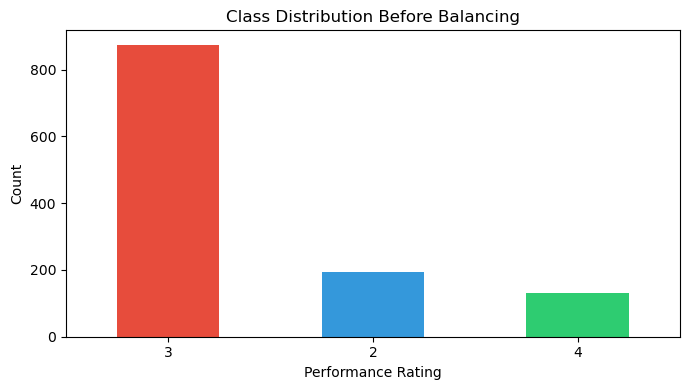

After Balancing:
PerformanceRating
4    874
3    874
2    874
Name: count, dtype: int64


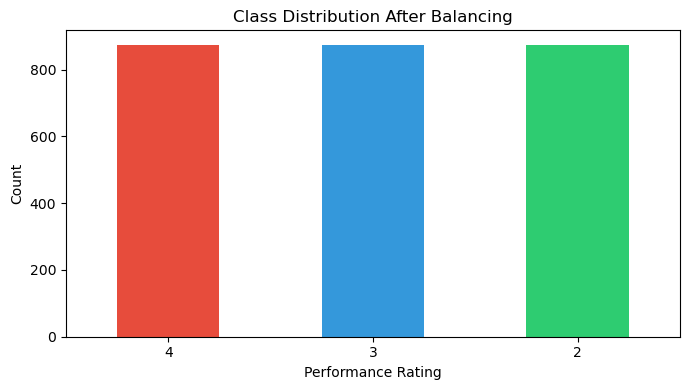

In [10]:
# Visualize class imbalance
plt.figure(figsize=(7, 4))
y.value_counts().plot(kind='bar', color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12'])
plt.title('Class Distribution Before Balancing')
plt.xlabel('Performance Rating')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Oversample minority classes using resample ---
df_balanced = pd.concat([X, y], axis=1)
target_col = 'PerformanceRating'

classes = df_balanced[target_col].unique()
max_count = df_balanced[target_col].value_counts().max()

balanced_dfs = []
for cls in classes:
    cls_df = df_balanced[df_balanced[target_col] == cls]
    cls_upsampled = resample(cls_df, replace=True, n_samples=max_count, random_state=42)
    balanced_dfs.append(cls_upsampled)

df_balanced = pd.concat(balanced_dfs).sample(frac=1, random_state=42).reset_index(drop=True)

X_balanced = df_balanced.drop(columns=[target_col])
y_balanced = df_balanced[target_col]

print("After Balancing:")
print(y_balanced.value_counts())

plt.figure(figsize=(7, 4))
y_balanced.value_counts().plot(kind='bar', color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12'])
plt.title('Class Distribution After Balancing')
plt.xlabel('Performance Rating')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**INSIGHT:**
- The original dataset was heavily skewed: ~90% of employees have Rating 3.
- After **oversampling**, each class has an equal number of samples.
- This prevents the model from being biased toward predicting class 3 for everything.
- Oversampling is applied **before** train-test split to avoid data leakage.

### 4.7 Feature Scaling

Apply **StandardScaler** to normalize numerical features so no single feature dominates due to scale differences.

In [12]:
from sklearn.model_selection import train_test_split

# Train-Test Split (before scaling)
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)

print("Train set:", X_train.shape)
print("Test set:", X_test.shape)

# Scale only numerical features
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print("\n Scaling applied to", len(num_cols), "numerical features")
print("\nSample scaled values (first 3 rows, first 5 cols):")
print(pd.DataFrame(X_train_scaled[num_cols[:5]]).head(3).round(3))


Train set: (2097, 53)
Test set: (525, 53)

 Scaling applied to 21 numerical features

Sample scaled values (first 3 rows, first 5 cols):
        Age  Gender  DistanceFromHome  EmpEducationLevel  \
659  -0.553   0.779            -0.843              1.011   
580   1.005  -1.284            -0.099              1.011   
1323  2.007   0.779             0.521              1.011   

      EmpEnvironmentSatisfaction  
659                        0.437  
580                        1.349  
1323                      -1.386  


**INSIGHT:**
- **StandardScaler** transforms each feature to zero mean and unit variance.
- Scaler is **fit on training data only**, then applied to test data — preventing data leakage.
- Tree-based models (Random Forest, XGBoost) don't require scaling, but it's essential for Logistic Regression and SVM.

### 4.8 Feature Importance Preview (Using Random Forest)

A quick look at which features matter most before full model training.

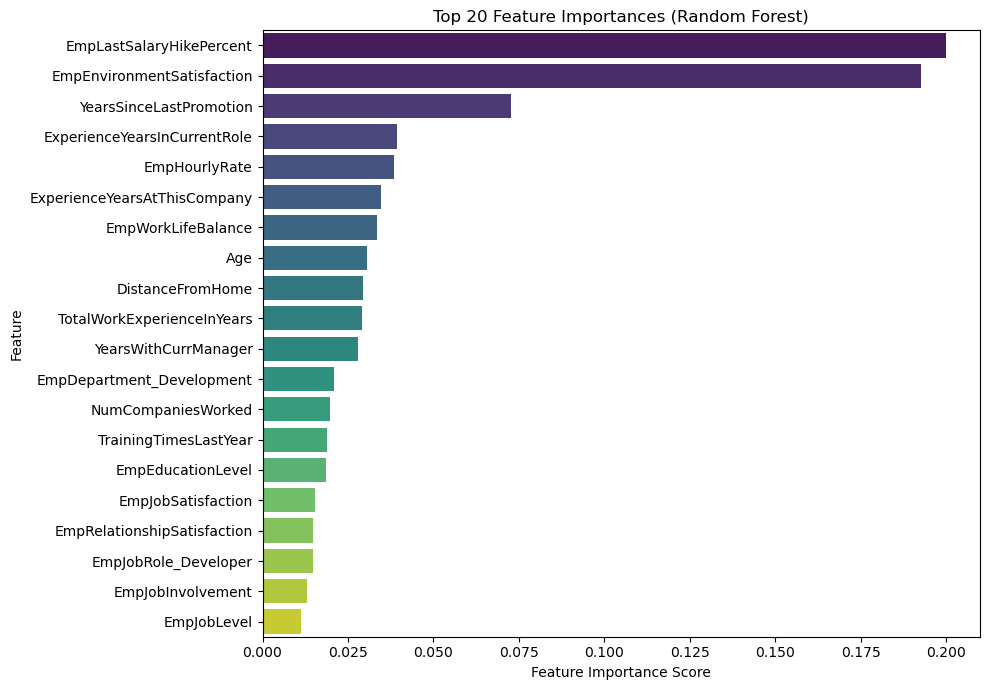

Top 20 Important Features:
                     Feature  Importance
    EmpLastSalaryHikePercent    0.199866
  EmpEnvironmentSatisfaction    0.192667
     YearsSinceLastPromotion    0.072772
ExperienceYearsInCurrentRole    0.039230
               EmpHourlyRate    0.038394
ExperienceYearsAtThisCompany    0.034797
          EmpWorkLifeBalance    0.033610
                         Age    0.030703
            DistanceFromHome    0.029502
  TotalWorkExperienceInYears    0.029209
        YearsWithCurrManager    0.027964
   EmpDepartment_Development    0.020989
          NumCompaniesWorked    0.019876
       TrainingTimesLastYear    0.018800
           EmpEducationLevel    0.018568
          EmpJobSatisfaction    0.015482
 EmpRelationshipSatisfaction    0.014794
        EmpJobRole_Developer    0.014743
           EmpJobInvolvement    0.013071
                 EmpJobLevel    0.011145


In [13]:
from sklearn.ensemble import RandomForestClassifier

# Quick RF for feature importance
rf_quick = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_quick.fit(X_train_scaled, y_train)

importance_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': rf_quick.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 7))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.show()

print("Top 20 Important Features:")
print(importance_df.to_string(index=False))


**INSIGHT:**
- **EmpLastSalaryHikePercent** dominates as the most important feature — consistent with all prior analyses.
- **EmpEnvironmentSatisfaction**, **EmpJobSatisfaction**, and **EmpWorkLifeBalance** rank in the top features.
- Many one-hot encoded department and role features rank lower, suggesting the numerical satisfaction/experience metrics carry more predictive power.
- This informs **feature selection** for leaner models.

### 4.9 Save Processed Data

Save the cleaned, encoded, scaled, and balanced datasets for use in model building.

In [20]:
import os

# ✅ Create the directory if it doesn't exist
save_dir = '../Src/Data_Processing'
os.makedirs(save_dir, exist_ok=True)

# Save balanced + scaled train/test sets
X_train_scaled.to_csv(f'{save_dir}/X_train.csv', index=False)
X_test_scaled.to_csv(f'{save_dir}/X_test.csv', index=False)
y_train.to_csv(f'{save_dir}/y_train.csv', index=False)
y_test.to_csv(f'{save_dir}/y_test.csv', index=False)

# Save column names for reference
pd.DataFrame({'columns': X_train_scaled.columns.tolist()}).to_csv(
    f'{save_dir}/feature_names.csv', index=False)

print("✅ Saved processed datasets to", save_dir)
print("  - X_train.csv:", X_train_scaled.shape)
print("  - X_test.csv :", X_test_scaled.shape)
print("  - y_train.csv:", y_train.shape)
print("  - y_test.csv :", y_test.shape)

✅ Saved processed datasets to ../Src/Data_Processing
  - X_train.csv: (2097, 53)
  - X_test.csv : (525, 53)
  - y_train.csv: (2097,)
  - y_test.csv : (525,)


## Preprocessing Summary

| Step | Action | Result |
|------|--------|--------|
| Missing Values | Check for nulls |No missing values |
| Drop Columns | Remove EmpNumber | Irrelevant ID column removed |
| Label Encoding | Gender, OverTime, Attrition | Converted to 0/1 |
| One-Hot Encoding | Department, JobRole, etc. | Dummies created |
| Class Balancing | Oversample minority classes | Equal class distribution |
| Train-Test Split | 80% train / 20% test | Stratified split |
| Feature Scaling | StandardScaler | Zero mean, unit variance |
| Feature Importance | Quick Random Forest | Top features identified |

**The data is now ready for Model Building (Step 5).**

**Top features to include in models:**
- `EmpLastSalaryHikePercent`
- `EmpEnvironmentSatisfaction`
- `EmpJobSatisfaction`
- `EmpWorkLifeBalance`
- `TotalWorkExperienceInYears`
- `EmpJobLevel`
- `EmpJobInvolvement`
- `ExperienceYearsAtThisCompany`
